# Lab 1
By: Bernard Tapiru Jr. & Hugh Angelo C. Sonon

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Defining system model
### Step response equation
The system is modeled as a third order LTI system with three distict time constants.
$$
c(t) = K ( 1 - Ae^{-t/\tau_1} - Be^{-t/\tau_2} - Ce^{-t/\tau_3} )
$$
Ideally: A + B + C = 1 for K.

In [2]:
def step_response_model(t, K, A, tau1, B, tau2, C, tau3):
    """
    Model for a step response with 3 time constants
    """
    return K * (1 - A * np.exp(-t / tau1) - B * np.exp(-t / tau2) - C * np.exp(-t / tau3))

## Loading the extracted data from the CSVs
Since the csv for the range 0 to 5 seconds is just a low-res version of the other two, 
ignore it.

Combine the fast part of the curve (0 to 1 sec) and the slow part of the curve (1 to 5 sec) for precise data.

In [3]:
df_fast = pd.read_csv('csv/0to1.csv')
df_slow = pd.read_csv('csv/1to5.csv')
df_final = pd.concat([df_fast, df_slow])
db_final = df_final.sort_values(by='t').drop_duplicates(subset=['t'])
# Drop possible negative values from the extraction
df_final = df_final[df_final['t'] >= 0]

Extract arrays for the optimizer

In [4]:
t_data = df_final['t'].values
v_data = df_final['v'].values

print(f"Total data points: {len(t_data)}")

Total data points: 139


### Initial Guesses
Based from the provided images,
$$
\lim_{t \to 5} c(t) \approx 4.0 \text{ V}
$$

Using the Final Value Theorem,
$$
\lim_{t \to \infty} c(t) = \lim_{t \to \infty} K ( 1 - A e^{-t/\tau_1} - B e^{-t/\tau_2} - C e^{-t/\tau_3} )
$$
$$
c(\infty) = K (1 - 0 - 0 - 0)
$$
$$
c(\infty) = K
$$
Since the system appears to settle at $y=4$ on the graph,
$$
c(\infty) = 4
$$
$$
K = 4
$$

Initial Guesses (p0): [K, A, tau1, B, tau2, C, tau3]
$$ K \approx 4 $$

From 0 to 0.1 sec, the graph shoots up immediately (0 to 0.8V)
$$\tau_1 \approx 0.1 $$

From 0.1 to 0.8, the change in slope of the curve decreases but is still significant
$$\tau_2 \approx 0.5 $$

From 0.8 to 5, the change is a slow and gradual climb
$$\tau_2 \approx 2.0 $$

For $c(0) = K (1 - A - B - C) = 0)$ to hold true, the weights $ A + B + C = 1.0 $
$$ A \approx 0.33 $$
$$ B \approx 0.33 $$
$$ C \approx 0.33 $$


In [5]:
p0_guess = [4.0, 0.333, 0.1, 0.333, 0.5, 0.334, 2.0]

### Finding the values using Non-Linear Least Squares optimization (Levenberg-Marquardt algorithm)

In [6]:
try:
    popt, pcov = curve_fit(step_response_model, t_data, v_data, p0=p0_guess, maxfev=20000)
    
    K, A, t1, B, t2, C, t3 = popt
    print(f"OPTIMIZED PARAMETERS:")
    print(f"Steady State Gain (K) = {K:.4f}")
    print(f"Individual component params (A,B,C) = (A={A:.4f}), (B={B:.4f}), (C={C:.4f})")
    print(f"Time Constants: τ1={t1:.4f}s, τ2={t2:.4f}s, τ3={t3:.4f}s")
    
except Exception as e:
    print(f"Curve fitting failed: {e}")
    print("Need to adjust the 'p0_guess' values closer to the graph.")

OPTIMIZED PARAMETERS:
Steady State Gain (K) = 4.0004
Individual component params (A,B,C) = (A=0.1125), (B=0.5064), (C=0.3825)
Time Constants: τ1=0.0941s, τ2=0.3225s, τ3=0.9951s


# Identification & Visualization

To summarize, our analysis indicates that the system can be modelled as follows.

$$c(t) \approx 4 (1 - 0.1125 e^{-t/0.0941} - 0.5064 e^{-t/0.3225} - 0.3825 e^{-t/0.9951})$$

Expanding would yield the individual exponential decays, which are also plotted below.

$$c(t) \approx 4 - 0.45 e^{-t/0.0941} - 2.0256 e^{-t/0.3225} - 1.53 e^{-t/0.9951}$$

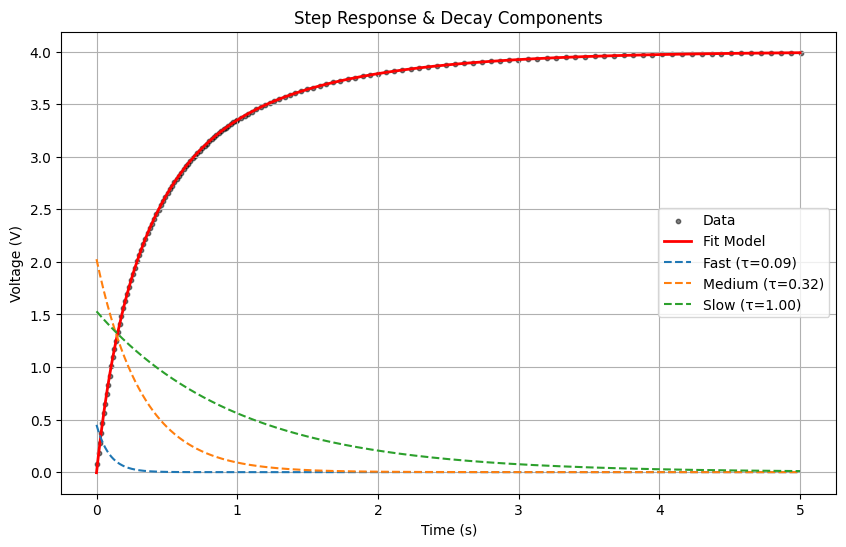

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(t_data, v_data, color='black', s=10, label='Data', alpha=0.5)

t_smooth = np.linspace(0, 5, 1000)
plt.plot(t_smooth, step_response_model(t_smooth, *popt), 'r-', linewidth=2, label='Fit Model')

plt.plot(t_smooth, K * A * np.exp(-t_smooth/t1), '--', label=f'Fast (τ={t1:.2f})')
plt.plot(t_smooth, K * B * np.exp(-t_smooth/t2), '--', label=f'Medium (τ={t2:.2f})')
plt.plot(t_smooth, K * C * np.exp(-t_smooth/t3), '--', label=f'Slow (τ={t3:.2f})')

plt.title("Step Response & Decay Components")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

The transfer function of the system can be obtained by first putting the equation into the s-domain using the Laplace transform.

$$L \{c(t) \} = L \{4 - 0.45 e^{-t/0.0941} - 2.0256 e^{-t/0.3225} - 1.53 e^{-t/0.9951} \} $$

$$C(s) = \frac{4}{s} - \frac{0.45}{s + \frac{1}{0.0941}} - \frac{2.0256}{s + \frac{1}{0.3225}} - \frac{1.53}{s + \frac{1}{0.9951}}$$

Since the input $R(s) = \frac{1}{s}$, the transfer function can then be obtained using the formula $C(s) = R(s) G(s)$.

$$C(s) = \frac{4}{s} - \frac{0.45}{s + \frac{1}{0.0941}} - \frac{2.0256}{s + \frac{1}{0.3225}} - \frac{1.53}{s + \frac{1}{0.9951}}$$

$$R(s)G(s) = \frac{4}{s} - \frac{0.45}{s + \frac{1}{0.0941}} - \frac{2.0256}{s + \frac{1}{0.3225}} - \frac{1.53}{s + \frac{1}{0.9951}}$$

$$G(s) = [\frac{4}{s} - \frac{0.45}{s + \frac{1}{0.0941}} - \frac{2.0256}{s + \frac{1}{0.3225}} - \frac{1.53}{s + \frac{1}{0.9951}}] \cdot \frac{1}{R(s)} $$


$$G(s) = [\frac{4}{s} - \frac{0.45}{s + \frac{1}{0.0941}} - \frac{2.0256}{s + \frac{1}{0.3225}} - \frac{1.53}{s + \frac{1}{0.9951}}] \cdot s $$


$$G(s) = 4 - \frac{0.45s}{s + \frac{1}{0.0941}} - \frac{2.0256s}{s + \frac{1}{0.3225}} - \frac{1.53s}{s + \frac{1}{0.9951}}$$

$$\boxed{G(s) = 4 - \frac{0.45s}{s + 10.6270} - \frac{2.0256s}{s + 3.1008} - \frac{1.53s}{s + 1.0049}}$$

For the s-plane plot, the poles of the system can be obtained by looking at the denominators. In this case, it's equivalent to $-a$, which is equivalent to $- \frac{1}{\tau}$. This was already indirectly calculated above.

$$a_1, a_2, a_3 = \{10.6270, 3.1008, 1.0049\}$$
$$\text{Poles} = \{-10.6270, -3.1008, -1.0049\}$$

These values can then be used to generate the pole plot.

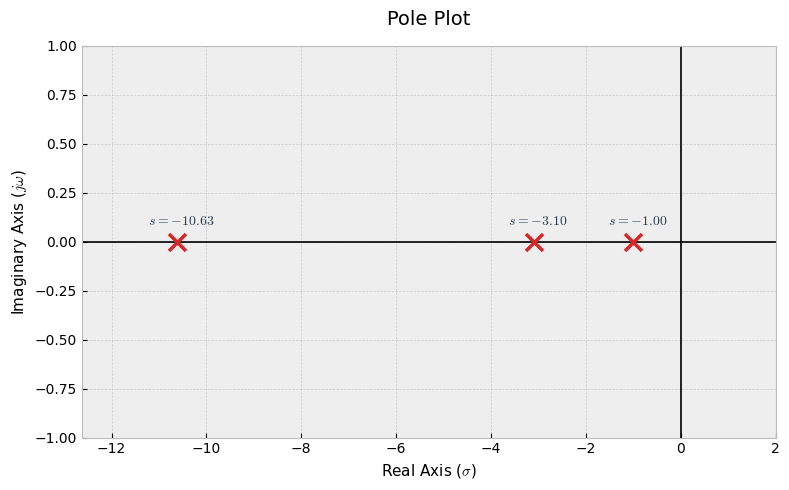

In [8]:
poles = [-10.627, -3.101, -1.005] 

plt.style.use('bmh')
fig, ax = plt.subplots(figsize=(8, 5))

ax.axhline(0, color='black', linewidth=1.2) # Real axis
ax.axvline(0, color='black', linewidth=1.2) # Imaginary axis

ax.scatter(poles, np.zeros_like(poles), 
           marker='x', 
           color='#d62728', 
           s=150, 
           linewidth=2.5, 
           label='System Poles',
           zorder=3)

for p in poles:
    ax.annotate(f'  $s = {p:.2f}$', (p, 0), 
                textcoords="offset points", 
                xytext=(0, 12), 
                ha='center', 
                fontsize=10, 
                fontweight='bold',
                color='#2c3e50')

ax.set_xlim(min(poles) - 2, 2)
ax.set_ylim(-1, 1)

ax.set_title('Pole Plot', fontsize=14, pad=15)
ax.set_xlabel('Real Axis ($\\sigma$)', fontsize=11)
ax.set_ylabel('Imaginary Axis ($j\\omega$)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Final Analysis

$$\boxed{G(s) = 4 - \frac{0.45s}{s + 10.6270} - \frac{2.0256s}{s + 3.1008} - \frac{1.53s}{s + 1.0049}}$$

Given the final transfer function, it can be said that the three physical processes are relatively imbalanced compared to each other. In our experimental results, two of the processes dominate the overall system in terms of their coefficients, with Component A having a coefficient that is three times smaller than the next largest (Component C).

> Individual component params (A,B,C) = (A=0.1125), (B=0.5064), (C=0.3825)
> 
> Time Constants: τ1=0.0941s, τ2=0.3225s, τ3=0.9951s

Component A also has the fastest time constant. Thus, it can be assumed that by the 1s mark, majority of the remaining "influence" on the graph is from the other two components.

Of the two dominant components, component B has the larger coefficient but also the lower time constant. Component C has a slightly smaller coefficient but a larger time constant.

Visually, this should correspond to Component B accounting for a large part of the rapid "rise" in the overall graph, being dominant in the midway portion. Component C then takes over and is responsible for the slow progression to the final steady-state value.